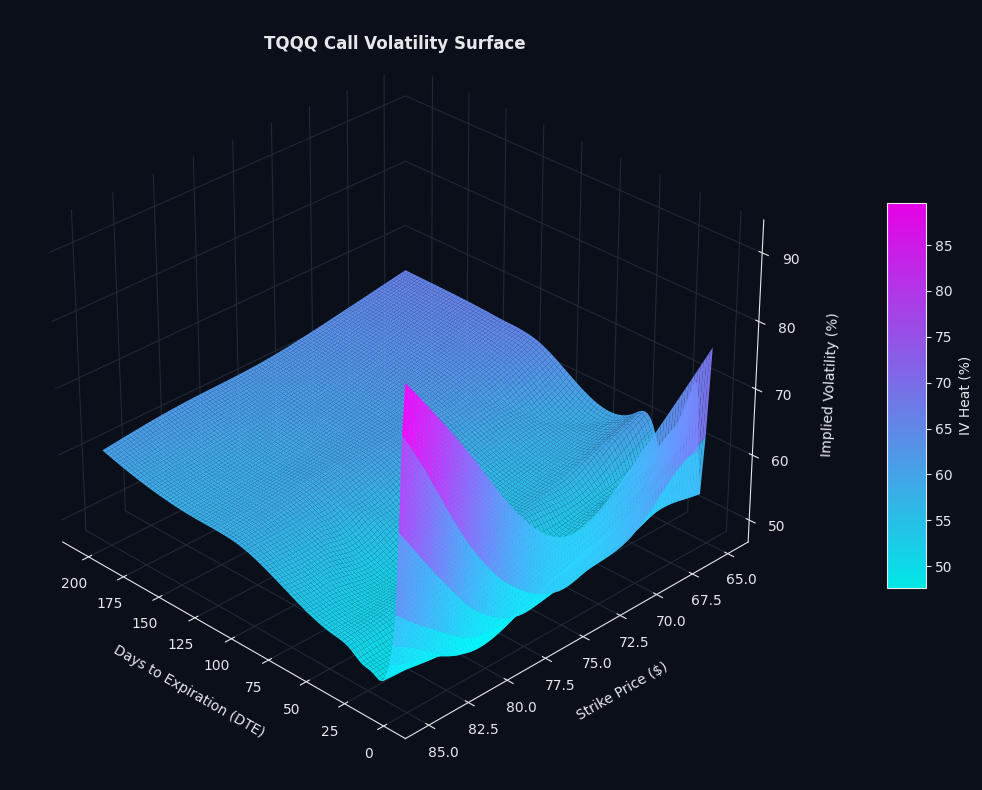

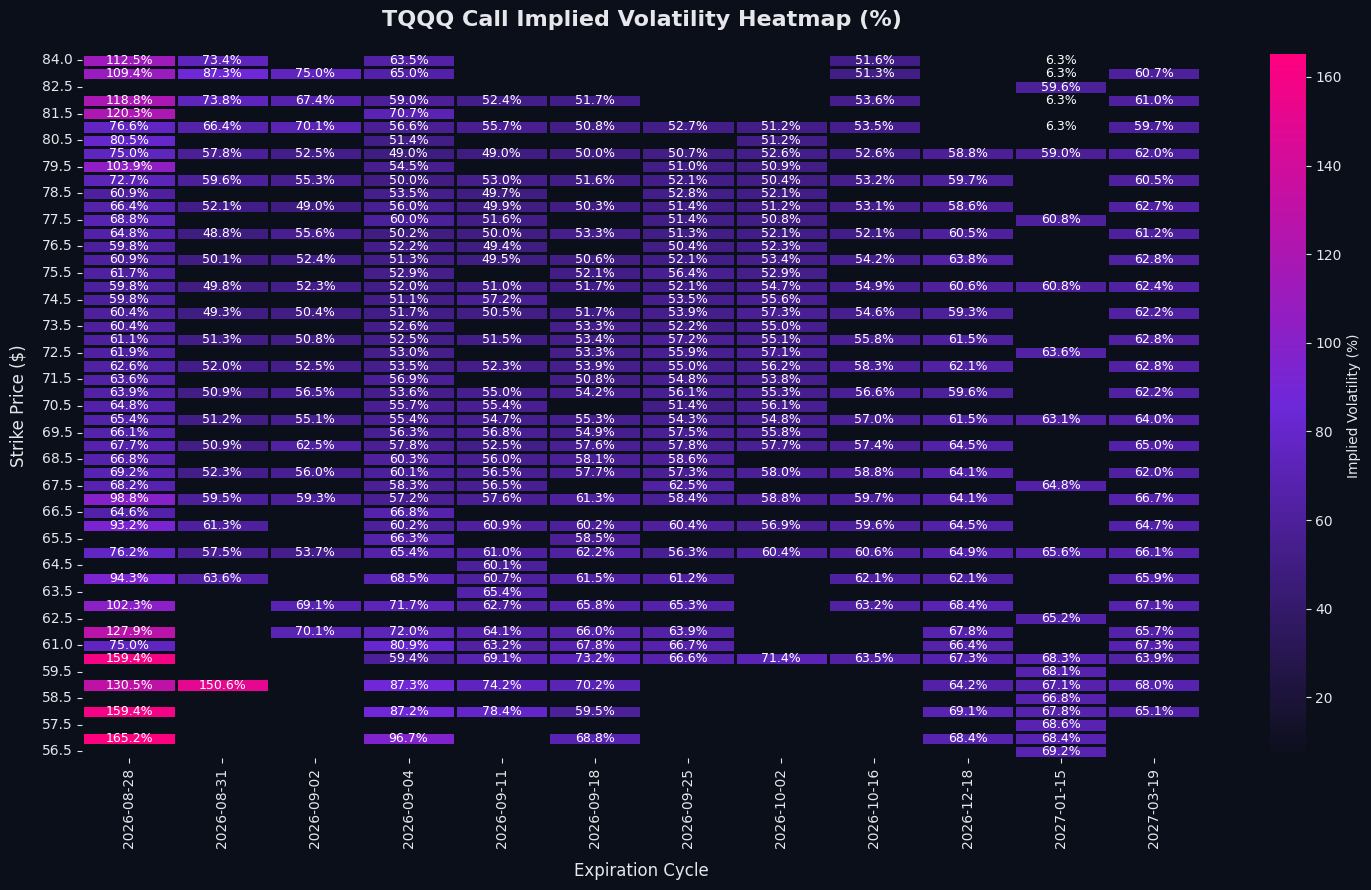

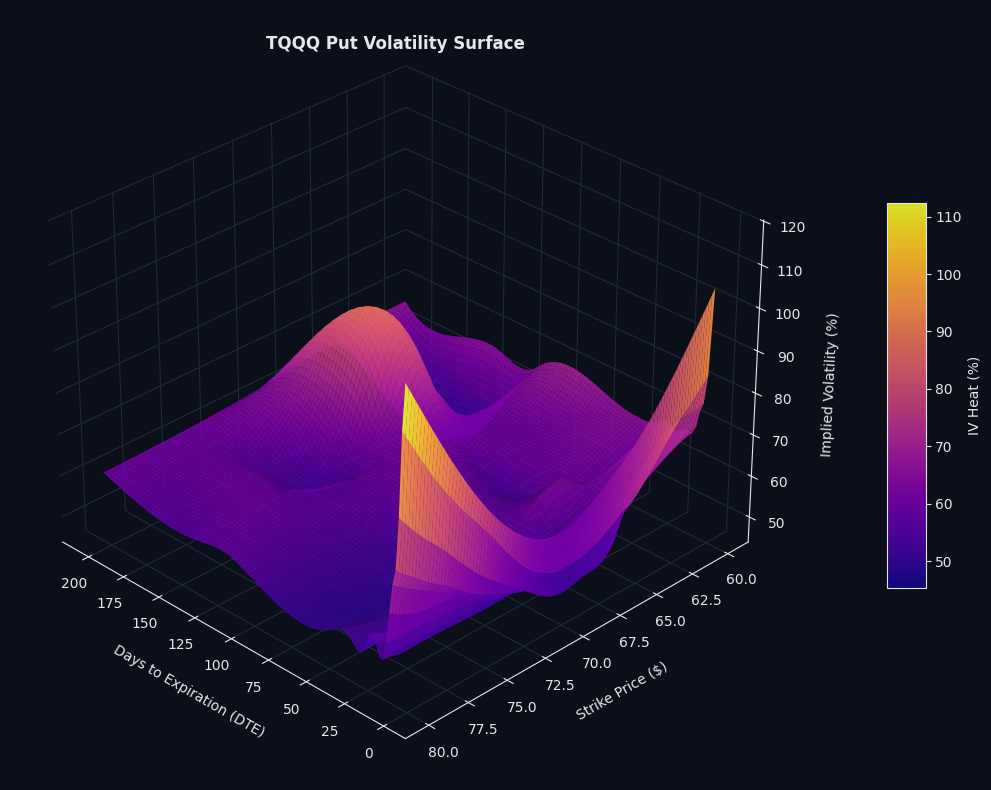

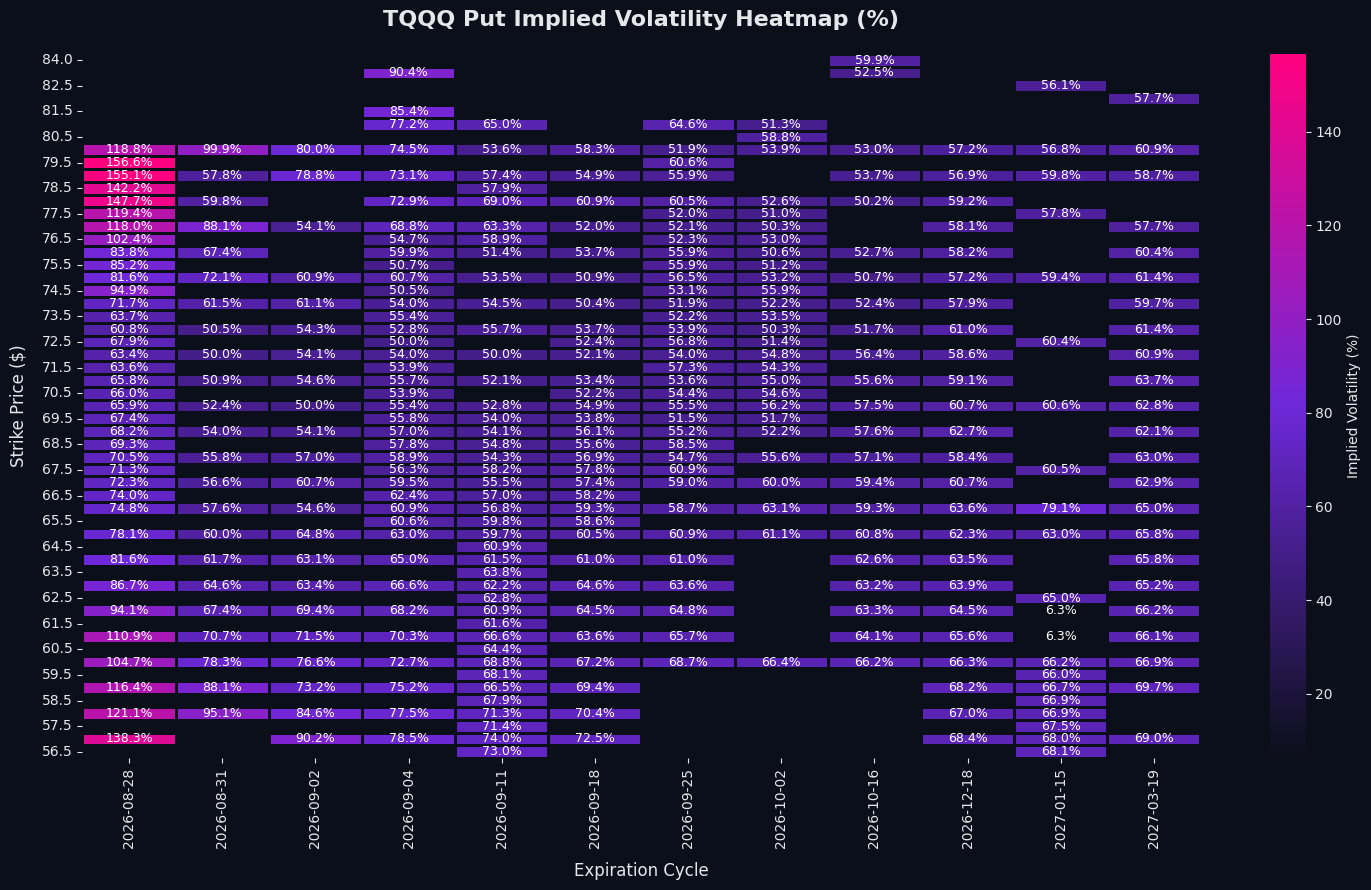

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy.interpolate import griddata  # Required for high-fidelity surface smoothing

# 1. Fetch TQQQ Data
ticker_sym = "TQQQ"
tk = yf.Ticker(ticker_sym)
hist = tk.history(period="5d")

# Support for fallback if fast_info behaves unexpectedly
try:
    spot_price = tk.fast_info['lastPrice']
except Exception:
    spot_price = hist['Close'].iloc[-1]

expirations = tk.options
all_data = []

# 2. Aggregate Option Chain
for exp in expirations[:12]:
    opt = tk.option_chain(exp)
    c, p = opt.calls.copy(), opt.puts.copy()
    
    c['type'], p['type'] = 'Call', 'Put'
    c['expiration'], p['expiration'] = exp, exp
    
    # Calculate Days to Expiration (DTE)
    dte = (datetime.strptime(exp, '%Y-%m-%d') - datetime.now()).days
    c['dte'], p['dte'] = dte, dte
    
    all_data.append(pd.concat([c, p]))

df = pd.concat(all_data)

# Filter for liquidity
df = df[(df['impliedVolatility'] > 0.05) & (df['openInterest'] > 5)]

# --- AESTHETIC CONFIGURATION ---
bg_color = '#0b0f19'      # Deep navy-black
grid_color = '#1f2937'    # Charcoal grid
cyan_neon = '#00f2ea'     # Accents & Callouts
magenta_neon = '#ff007f'  # Highlights
text_color = '#e5e7eb'    # Off-white text

plt.rcParams.update({
    'axes.facecolor': bg_color,
    'figure.facecolor': bg_color,
    'axes.edgecolor': text_color,
    'axes.labelcolor': text_color,
    'xtick.color': text_color,
    'ytick.color': text_color,
    'text.color': text_color,
    'grid.color': grid_color,
    'font.family': 'sans-serif'
})

# Custom Cyberpunk Heatmap Palette (Dark Navy -> Glowing Violet -> Hot Pink)
cyber_cmap = sns.blend_palette(['#0b0f19', '#6d28d9', magenta_neon], as_cmap=True)

# Function to generate 3D plots
def plot_3d_surface(option_type, color_map, title):
    subset = df[df['type'] == option_type]
    pivot = subset.pivot_table(index='strike', columns='dte', values='impliedVolatility').dropna()
    
    if pivot.empty: return
    
    # Raw coordinates
    raw_x = pivot.columns.values
    raw_y = pivot.index.values
    
    # Generate a highly dense, uniform coordinate grid
    dense_x = np.linspace(raw_x.min(), raw_x.max(), 100)
    dense_y = np.linspace(raw_y.min(), raw_y.max(), 100)
    X_dense, Y_dense = np.meshgrid(dense_x, dense_y)
    
    # Flatten the raw coordinates and data for interpolation mapping
    points = []
    values = []
    for s in raw_y:
        for d in raw_x:
            points.append((d, s))
            values.append(pivot.loc[s, d] * 100)
            
    # Apply cubic interpolation to fill data gaps seamlessly
    Z_dense = griddata(points, values, (X_dense, Y_dense), method='cubic')
    
    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Render with lighting shades enabled and zero-width borders for a continuous liquid look
    surf = ax.plot_surface(X_dense, Y_dense, Z_dense, cmap=color_map, 
                           edgecolor='none', 
                           linewidth=0,          # Strips out the internal square lines entirely
                           rstride=1, cstride=1, # Sampling frequency set to maximum fidelity
                           shade=True,           # Enables vector lighting calculation across curves
                           antialiased=True,     # Eliminates pixel jaggedness on borders
                           alpha=0.9)
    
    # Modernized Public Matplotlib API for 3D backgrounds
    ax.set_facecolor(bg_color)
    pane_rgba = (0.043, 0.059, 0.098, 1.0)
    ax.xaxis.set_pane_color(pane_rgba)
    ax.yaxis.set_pane_color(pane_rgba)
    ax.zaxis.set_pane_color(pane_rgba)
    
    # Keep background wall grids on, while keeping surface mesh off
    ax.grid(True, color=grid_color, linestyle=':')
    
    # Adjusted title height (y=0.95) to match portfolio layouts
    ax.set_title(f'{ticker_sym} {title} Volatility Surface', fontsize=12, fontweight='bold', y=1.02)
    ax.set_xlabel('Days to Expiration (DTE)', labelpad=10)
    ax.set_ylabel('Strike Price ($)', labelpad=10)
    ax.set_zlabel('Implied Volatility (%)', labelpad=10)
    
    cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
    cbar.set_label('IV Heat (%)', color=text_color)
    cbar.ax.yaxis.set_tick_params(color=text_color)
    plt.setp(plt.getp(cbar.ax, 'yticklabels'), color=text_color)
    
    ax.view_init(30, 135)
    plt.tight_layout()

# Function to generate Heatmaps
def plot_iv_heatmap(option_type, color_map):
    # Filter for strikes within 20% of spot for readability
    subset = df[(df['type'] == option_type) & 
                (df['strike'] > spot_price * 0.8) & 
                (df['strike'] < spot_price * 1.2)]
    
    pivot = subset.pivot_table(index='strike', columns='expiration', values='impliedVolatility').sort_index(ascending=False)
    
    if pivot.empty: return
    
    pivot_pct = pivot * 100
    
    plt.figure(figsize=(15, 9))
    
    # Generate heatmap using the unified cyberpunk palette framework
    ax = sns.heatmap(pivot_pct, cmap=color_map, annot=True, fmt=".1f", 
                     linewidths=.75, linecolor=bg_color,
                     cbar_kws={'label': 'Implied Volatility (%)'},
                     annot_kws={"size": 9, "weight": "medium"})
    
    # Formatting annotation text strings cleanly
    for t in ax.texts: 
        if t.get_text() != "nan":
            t.set_text(t.get_text() + "%")
            t.set_color('#ffffff')  # Keep text sharp inside cells
    
    plt.title(f'{ticker_sym} {option_type} Implied Volatility Heatmap (%)', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Expiration Cycle', fontsize=12, labelpad=10)
    plt.ylabel('Strike Price ($)', fontsize=12, labelpad=10)
    
    # Clean up layout structure borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()

# --- EXECUTE PLOTS ---

# Call Graphics (Using 'cool' palette for smooth Cyan-to-Magenta 3D rendering)
plot_3d_surface('Call', 'cool', 'Call')
plot_iv_heatmap('Call', cyber_cmap)

# Put Graphics (Using 'plasma' palette for deep violet-to-gold 3D tracking)
plot_3d_surface('Put', 'plasma', 'Put')
plot_iv_heatmap('Put', cyber_cmap)

plt.show()

In [2]:

import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from scipy.stats import norm

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ----------------------------------------------------------------------
# 1. Fetch Data
# ----------------------------------------------------------------------
ticker_sym = "TQQQ"
tk = yf.Ticker(ticker_sym)
hist = tk.history(period="5d")

try:
    spot_price = tk.fast_info['lastPrice']
except Exception:
    spot_price = hist['Close'].iloc[-1]

expirations = tk.options
all_data = []

# ----------------------------------------------------------------------
# 2. Aggregate Option Chain
# ----------------------------------------------------------------------
for exp in expirations[:12]:
    opt = tk.option_chain(exp)
    c, p = opt.calls.copy(), opt.puts.copy()

    c['type'], p['type'] = 'Call', 'Put'
    c['expiration'], p['expiration'] = exp, exp

    dte = (datetime.strptime(exp, '%Y-%m-%d') - datetime.now()).days
    c['dte'], p['dte'] = dte, dte

    all_data.append(pd.concat([c, p]))

df = pd.concat(all_data)

# --- LIQUIDITY / DATA-QUALITY FILTER ---
# The extra spread filter is what removes the stale, wide-quoted deep-OTM strikes
# that spike an illiquid surface. Relax MAX_REL_SPREAD if you lose too many strikes.
MAX_REL_SPREAD = 0.60   # drop quotes wider than 60% of mid (stale / no real market)

mid = (df['bid'] + df['ask']) / 2.0
rel_spread = (df['ask'] - df['bid']) / mid.replace(0, np.nan)

df = df[
    (df['impliedVolatility'] > 0.05) &
    (df['impliedVolatility'] < 3.0) &
    ((df['openInterest'] > 1) | (df['volume'] > 0)) &
    (df['bid'] > 0.01) &
    (df['ask'] >= df['bid']) &
    (rel_spread < MAX_REL_SPREAD)
].copy()

# ----------------------------------------------------------------------
# 3. Black-Scholes Delta (vectorised)
# ----------------------------------------------------------------------
RISK_FREE = 0.045
DIV_YIELD = 0.0


def bs_delta_vec(S, K, T, r, q, sigma, is_call):
    """Vectorised BS delta. Put delta returned negative (standard convention)."""
    K = np.asarray(K, dtype=float)
    T = np.asarray(T, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    is_call = np.asarray(is_call, dtype=bool)

    valid = (T > 0) & (sigma > 0)
    with np.errstate(divide='ignore', invalid='ignore'):
        d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    call_delta = np.exp(-q * T) * norm.cdf(d1)
    put_delta = np.exp(-q * T) * (norm.cdf(d1) - 1.0)
    out = np.where(is_call, call_delta, put_delta)
    return np.where(valid, out, np.nan)


df['T_years'] = df['dte'] / 365.0
df['delta'] = bs_delta_vec(
    S=spot_price, K=df['strike'].values, T=df['T_years'].values,
    r=RISK_FREE, q=DIV_YIELD, sigma=df['impliedVolatility'].values,
    is_call=(df['type'] == 'Call').values,
)

# ----------------------------------------------------------------------
# 4. Aesthetic Config (Plotly)
# ----------------------------------------------------------------------
bg_color = '#0b0f19'
grid_color = '#1f2937'
pane_color = '#0b0f19'
cyan_neon = '#00f2ea'
magenta_neon = '#ff007f'
amber_neon = '#fbbf24'
violet_neon = '#a78bfa'
text_color = '#e5e7eb'

PLASMA = 'Plasma'                                  # put surface
COOL = [[0.0, '#00ffff'], [1.0, '#ff00ff']]        # call surface (matplotlib 'cool')
CYBER = [[0.0, '#0b0f19'], [0.5, '#6d28d9'], [1.0, magenta_neon]]  # heatmaps

BASE_LAYOUT = dict(paper_bgcolor=bg_color, plot_bgcolor=bg_color,
                   font=dict(color=text_color, family='sans-serif'))

SCENE = dict(
    xaxis=dict(title='Days to Expiration (DTE)', backgroundcolor=pane_color,
               gridcolor=grid_color, color=text_color, showbackground=True),
    yaxis=dict(title='Strike Price ($)', backgroundcolor=pane_color,
               gridcolor=grid_color, color=text_color, showbackground=True),
    zaxis=dict(title='Implied Volatility (%)', backgroundcolor=pane_color,
               gridcolor=grid_color, color=text_color, showbackground=True),
    # Camera/aspect matched to the preferred "image 2" framing: low-elevation
    # profile view, DTE=0 nearest the viewer receding back-left, Strike back-right,
    # IV vertical on the left, peaks standing up.
    camera=dict(eye=dict(x=-1.8, y=1.8, z=0.5)),
    aspectmode='manual', aspectratio=dict(x=1.5, y=1.2, z=0.7),
)


def _centered_title(text):
    return dict(text=text, font=dict(size=18, color=text_color), x=0.5, xanchor='center')


def get_strike_at_delta(subset, target_delta, dte_value):
    """For a given DTE, interpolate the strike at a target delta (puts<0, calls>0)."""
    dte_slice = subset[subset['dte'] == dte_value].sort_values('strike')
    if len(dte_slice) < 2:
        return np.nan
    deltas = dte_slice['delta'].values
    strikes = dte_slice['strike'].values
    if deltas[0] > deltas[-1]:
        deltas, strikes = deltas[::-1], strikes[::-1]
    if target_delta < deltas.min() or target_delta > deltas.max():
        return np.nan
    return np.interp(target_delta, deltas, strikes)


# ----------------------------------------------------------------------
# 5. 3D Surface + delta overlays  (winsorised + smoothed for a clean read)
# ----------------------------------------------------------------------
def plot_3d_surface_with_delta(option_type, color_scale, title,
                               strike_pct_range=0.40, delta_bands=None,
                               clip_pct=97.0, smooth_sigma=1.8, surface_height=820):
    """
    clip_pct    : winsorise IV at this percentile so a few stale deep-OTM quotes
                  don't spike the surface (set to 100 to disable).
    smooth_sigma: Gaussian blur on the interpolated grid (set to 0 to disable).
    delta_bands : list of (delta, label, color); pass None to hide overlays.
    """
    subset = df[df['type'] == option_type].copy()
    lo, hi = spot_price * (1 - strike_pct_range), spot_price * (1 + strike_pct_range)
    subset = subset[(subset['strike'] >= lo) & (subset['strike'] <= hi)]

    pivot = subset.pivot_table(index='strike', columns='dte', values='impliedVolatility')
    pivot = pivot.dropna(thresh=3, axis=0).dropna(thresh=3, axis=1)
    if pivot.empty or pivot.shape[0] < 3 or pivot.shape[1] < 3:
        print(f"[{option_type}] Not enough data after filtering.")
        return None

    print(f"[{option_type}] Surface: {pivot.shape[0]} strikes x {pivot.shape[1]} DTEs")

    raw_x, raw_y = pivot.columns.values, pivot.index.values   # DTE, Strike

    D, S = np.meshgrid(raw_x, raw_y)
    Z_raw = pivot.values * 100.0
    mask = ~np.isnan(Z_raw)
    points = np.column_stack([D[mask], S[mask]])
    values = Z_raw[mask]

    # Winsorise the extreme deep-OTM IVs that cause spikes
    if clip_pct < 100:
        cap = np.nanpercentile(values, clip_pct)
        values = np.clip(values, None, cap)

    dense_x = np.linspace(raw_x.min(), raw_x.max(), 120)
    dense_y = np.linspace(raw_y.min(), raw_y.max(), 120)
    X_dense, Y_dense = np.meshgrid(dense_x, dense_y)

    Z_cubic = griddata(points, values, (X_dense, Y_dense), method='cubic')
    Z_linear = griddata(points, values, (X_dense, Y_dense), method='linear')
    Z_nearest = griddata(points, values, (X_dense, Y_dense), method='nearest')
    Z_dense = np.where(np.isnan(Z_cubic), Z_linear, Z_cubic)
    Z_dense = np.where(np.isnan(Z_dense), Z_nearest, Z_dense)

    # Smooth the interpolated grid for a clean, liquid-looking surface
    if smooth_sigma and smooth_sigma > 0:
        Z_dense = gaussian_filter(Z_dense, sigma=smooth_sigma, mode='nearest')

    fig = go.Figure()
    fig.add_trace(go.Surface(
        x=dense_x, y=dense_y, z=Z_dense, colorscale=color_scale, opacity=1.0,
        lighting=dict(ambient=0.75, diffuse=0.6, specular=0.05, roughness=0.9),
        colorbar=dict(title=dict(text='IV Heat (%)', font=dict(color=text_color)),
                      tickfont=dict(color=text_color), len=0.6, thickness=14),
        name='IV surface', showscale=True,
        hovertemplate='DTE %{x:.0f}<br>Strike $%{y:.2f}<br>IV %{z:.1f}%<extra></extra>',
    ))

    z_floor = float(np.nanmin(Z_dense))
    fig.add_trace(go.Scatter3d(
        x=[raw_x.min(), raw_x.max()], y=[spot_price, spot_price], z=[z_floor, z_floor],
        mode='lines', line=dict(color=cyan_neon, width=4, dash='dash'),
        name=f'Spot ${spot_price:.2f}',
    ))

    if delta_bands:
        for delta_val, label, color in delta_bands:
            d_dtes, d_strikes, d_ivs = [], [], []
            for dte_v in sorted(subset['dte'].unique()):
                k = get_strike_at_delta(subset, delta_val, dte_v)
                if pd.notna(k) and raw_y.min() <= k <= raw_y.max():
                    ix = int(np.argmin(np.abs(dense_x - dte_v)))
                    iy = int(np.argmin(np.abs(dense_y - k)))
                    iv_at_point = Z_dense[iy, ix]
                    if pd.notna(iv_at_point):
                        d_dtes.append(dte_v); d_strikes.append(k)
                        d_ivs.append(iv_at_point + 1.5)
            if len(d_dtes) >= 2:
                fig.add_trace(go.Scatter3d(
                    x=d_dtes, y=d_strikes, z=d_ivs, mode='lines+markers',
                    line=dict(color=color, width=4),
                    marker=dict(size=3.5, color=color, line=dict(color='white', width=0.5)),
                    name=label,
                    hovertemplate=(label + '<br>DTE %{x:.0f}<br>Strike $%{y:.2f}'
                                   '<br>IV %{z:.1f}%<extra></extra>'),
                ))

    fig.update_layout(
        title=_centered_title(f'{ticker_sym} {title} Volatility Surface'),
        scene=SCENE,
        legend=dict(bgcolor=bg_color, bordercolor=grid_color, borderwidth=1, font=dict(size=11)),
        autosize=True, height=surface_height, margin=dict(l=0, r=0, t=55, b=0),
        **BASE_LAYOUT,
    )
    return fig


# ----------------------------------------------------------------------
# 6. 2D companion: strike-by-delta and IV-by-delta vs DTE
# ----------------------------------------------------------------------
def plot_delta_iv_table(option_type, delta_targets):
    subset = df[df['type'] == option_type].copy()
    dtes = sorted(subset['dte'].unique())
    palette = [magenta_neon, amber_neon, cyan_neon, violet_neon]

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(f'{option_type}: Strike by Delta vs DTE',
                        f'{option_type}: IV by Delta vs DTE'),
        horizontal_spacing=0.10,
    )

    for i, dv in enumerate(delta_targets):
        strikes, ivs, valid_dtes = [], [], []
        for d in dtes:
            k = get_strike_at_delta(subset, dv, d)
            if pd.notna(k):
                slice_df = subset[subset['dte'] == d].sort_values('strike')
                if len(slice_df) >= 2:
                    iv_interp = np.interp(k, slice_df['strike'].values,
                                          slice_df['impliedVolatility'].values)
                    strikes.append(k); ivs.append(iv_interp * 100); valid_dtes.append(d)
        color = palette[i % len(palette)]
        label = f'Δ = {dv:+.2f}'
        fig.add_trace(go.Scatter(x=valid_dtes, y=strikes, mode='lines+markers',
                                 name=label, legendgroup=label,
                                 line=dict(color=color, width=2), marker=dict(size=7, color=color),
                                 hovertemplate=label + '<br>DTE %{x}<br>Strike $%{y:.2f}<extra></extra>'),
                      row=1, col=1)
        fig.add_trace(go.Scatter(x=valid_dtes, y=ivs, mode='lines+markers',
                                 name=label, legendgroup=label, showlegend=False,
                                 line=dict(color=color, width=2), marker=dict(size=7, color=color),
                                 hovertemplate=label + '<br>DTE %{x}<br>IV %{y:.1f}%<extra></extra>'),
                      row=1, col=2)

    fig.add_hline(y=spot_price, line=dict(color=cyan_neon, dash='dash', width=1.2),
                  annotation_text=f'Spot ${spot_price:.2f}',
                  annotation_font_color=cyan_neon, row=1, col=1)

    fig.update_xaxes(title_text='DTE', gridcolor=grid_color, zeroline=False, row=1, col=1)
    fig.update_xaxes(title_text='DTE', gridcolor=grid_color, zeroline=False, row=1, col=2)
    fig.update_yaxes(title_text='Strike ($)', gridcolor=grid_color, zeroline=False, row=1, col=1)
    fig.update_yaxes(title_text='Implied Volatility (%)', gridcolor=grid_color, zeroline=False, row=1, col=2)

    fig.update_layout(
        title=_centered_title(f'{ticker_sym} {option_type} — Delta-Targeted Entry View'),
        legend=dict(bgcolor=bg_color, bordercolor=grid_color, borderwidth=1),
        autosize=True, margin=dict(l=60, r=20, t=70, b=50), **BASE_LAYOUT,
    )
    for ann in fig.layout.annotations:
        ann.font.color = text_color
    return fig


# ----------------------------------------------------------------------
# 7. IV heatmap  (categorical axes -> even cells, no crowding)
# ----------------------------------------------------------------------
def plot_iv_heatmap(option_type, color_scale, strike_pct_range=0.40,
                    height=None, row_px=30, max_height=900, min_height=480,
                    annotate=None):
    """
    Compact, scroll-friendly heatmap.
      height     : force a total px height (overrides the auto logic).
      row_px     : target px per strike row before the cap kicks in.
      max_height : hard cap so high-strike-count tickers (QQQ, SPY) fit one screen.
      annotate   : True/False to force per-cell % labels; None = auto (show only
                   when cells are tall enough, else rely on colour + hover).
    """
    subset = df[(df['type'] == option_type) &
                (df['strike'] > spot_price * (1 - strike_pct_range)) &
                (df['strike'] < spot_price * (1 + strike_pct_range))]

    pivot = subset.pivot_table(index='strike', columns='expiration',
                               values='impliedVolatility').sort_index(ascending=False)
    if pivot.empty:
        return None

    pivot_pct = pivot * 100
    n_rows = pivot_pct.shape[0]

    # Height grows with strikes but is capped so it never needs scrolling.
    if height is None:
        height = int(min(max_height, max(min_height, row_px * n_rows)))
    cell_h = height / max(n_rows, 1)

    # Labels only when cells are tall enough; font scales with cell height.
    show_text = (cell_h >= 17) if annotate is None else bool(annotate)
    font_size = int(np.clip(round(cell_h * 0.5), 6, 11))

    hm_kwargs = dict(
        z=pivot_pct.values,
        x=[str(c) for c in pivot_pct.columns],
        y=[f'${s:.2f}' for s in pivot_pct.index],
        colorscale=color_scale, xgap=1, ygap=1,
        colorbar=dict(title=dict(text='IV (%)', font=dict(color=text_color)),
                      tickfont=dict(color=text_color)),
        hovertemplate='Exp %{x}<br>Strike %{y}<br>IV %{z:.1f}%<extra></extra>',
    )
    if show_text:
        hm_kwargs['text'] = np.where(
            np.isnan(pivot_pct.values), '',
            np.vectorize(lambda v: f'{v:.1f}%')(np.nan_to_num(pivot_pct.values)))
        hm_kwargs['texttemplate'] = '%{text}'
        hm_kwargs['textfont'] = dict(size=font_size, color='#ffffff')

    fig = go.Figure(go.Heatmap(**hm_kwargs))

    # Thin strike ticks so labels don't overlap when there are many strikes.
    ylabels = [f'${s:.2f}' for s in pivot_pct.index]
    step = max(1, int(np.ceil(n_rows / 28)))
    ytickvals = ylabels[::step]

    fig.update_layout(
        title=_centered_title(f'{ticker_sym} {option_type} Implied Volatility Heatmap (%)'),
        xaxis=dict(title='Expiration Cycle', color=text_color, type='category',
                   tickangle=-30, showgrid=False),
        yaxis=dict(title='Strike Price ($)', color=text_color, type='category',
                   showgrid=False, tickmode='array', tickvals=ytickvals),
        autosize=True, height=height, margin=dict(l=70, r=20, t=70, b=70), **BASE_LAYOUT,
    )
    return fig


# ----------------------------------------------------------------------
# 8. Notebook rendering helper
# ----------------------------------------------------------------------
# responsive=True -> the chart fills the output cell's width and live-resizes
# when the notebook / browser is resized. Combined with autosize=True on each
# layout, nothing is pinned to a fixed pixel size.
RESPONSIVE_CONFIG = {'responsive': True, 'displaylogo': False, 'scrollZoom': True}


def show(fig, height=None):
    """
    Render a figure inline in Jupyter, fitting the cell width.
    Pass height=600 (px) if a chart needs more vertical room (e.g. tall heatmaps);
    width always stays responsive.
    """
    if fig is None:
        return
    if height is not None:
        fig.update_layout(height=height)
    fig.show(config=RESPONSIVE_CONFIG)


# ----------------------------------------------------------------------
# 9. EXECUTE  (run cell-by-cell in a notebook, or all at once)
# ----------------------------------------------------------------------
if __name__ == '__main__':
    put_delta_bands = [
        (-0.30, 'Δ = -0.30 (aggressive)', magenta_neon),
        (-0.20, 'Δ = -0.20 (standard)',   amber_neon),
        (-0.10, 'Δ = -0.10 (defensive)',  cyan_neon),
    ]
    call_delta_bands = [
        (0.30, 'Δ = 0.30 (aggressive)',  magenta_neon),
        (0.20, 'Δ = 0.20 (standard)',    amber_neon),
        (0.10, 'Δ = 0.10 (defensive)',   cyan_neon),
    ]

    figs = [
        plot_3d_surface_with_delta('Put', PLASMA, 'Put', delta_bands=put_delta_bands),
        plot_delta_iv_table('Put', delta_targets=[-0.30, -0.20, -0.15, -0.10]),
        plot_3d_surface_with_delta('Call', COOL, 'Call', delta_bands=call_delta_bands),
        plot_delta_iv_table('Call', delta_targets=[0.30, 0.20, 0.15, 0.10]),
        plot_iv_heatmap('Put', CYBER, strike_pct_range=0.40),
        plot_iv_heatmap('Call', CYBER, strike_pct_range=0.40),
    ]

    # Render inline; each fills the cell width and resizes with the window.
    for f in figs:
        show(f)

[Put] Surface: 56 strikes x 12 DTEs
[Call] Surface: 55 strikes x 12 DTEs
